In [ ]:
%pip install qiskit matplotlib qiskit[visualization]
%pip install qiskit-aer

In [2]:
import os
QISKIT_APIKEY = os.getenv("QISKIT_APIKEY")
print(QISKIT_APIKEY)

pjQIiifWy8a_GmVE3wmJe8dKruDcIuMjh8Z82PSAjPns


In [3]:
# 양자컴퓨팅 서비스에 연결
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    token=QISKIT_APIKEY,
    channel="ibm_quantum_platform"
)
backend = service.least_busy(
    operational=True, simulator=False
)
print(backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-04-13 09:19:20,821: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-13 09:19:25,971: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-13 09:19:26,691: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-13 09:19:30,180: Using instance: open-instance, plan: open


ibm_fez


### Quantum Teleportation 구현
Alice의 큐비트 \ket{\psi}를 복사
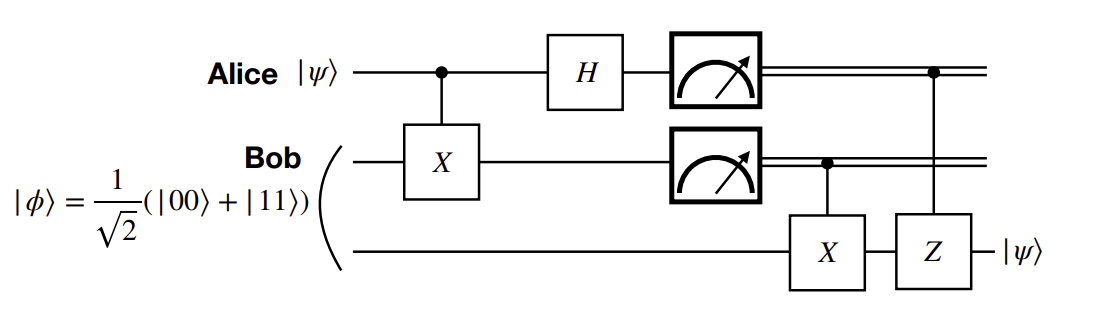

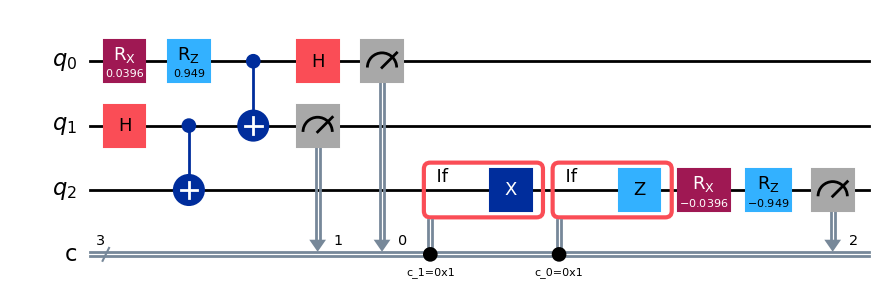

In [ ]:
# 퀀텀 상태 복사 회로 구현
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from random import random # 임의의 값으로 회전
import numpy as np        # radian 계산을 위해

qc = QuantumCircuit(3, 3) # 3개의 큐비트, 3개의 고전 비트 설정
theta = random()          # 0~1 사이의 임의의 값
phi = random()

# Alice: 0번째 큐비트
qc.rx(theta*np.pi/2, 0) # 각, 큐비트 넘버
qc.rz(phi*np.pi/2, 0)

# Bob: 1,2번째 큐비트
qc.h(1)     # Hadamard 게이트
qc.cx(1, 2) # CNOT 게이트: 1번째 게이트 control, 2번째 게이트 target

qc.cx(0, 1)
qc.h(0)
qc.measure(0, 0) # 0번째 큐비트 -> 0번째 고전 비트
qc.measure(1, 1) # 1번째 큐비트 -> 1번째 고전 비트

with qc.if_test((1,1)):
    qc.x(2)
with qc.if_test((0,1)):
    qc.z(2)

# Bob의 복사된 큐비트 상태 확인
qc.rx(-theta*np.pi/2, 2)
qc.rz(-phi*np.pi/2, 2)

qc.measure(2,2) # 2번째 큐비트 -> 2번째 고전 비트

qc.draw(output="mpl", filename="quantum_transportation.png")


In [ ]:
# 실제 양자컴퓨터 실행 코드 (크레딧 사용)
sampler = Sampler(backend)
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
job = sampler.run([isa_circuit], shots=1024)
print(f"job id: {job.job_id()}")

result = job.result()
print(result[0].data) # 현재 데이터 객체에 들어있는 모든 속성 이름 출력 (확인)
print(result[0].data.c.get_counts())

job id: d7e3uvu5nvhs73a6an0g
DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=3>))
{'011': 264, '010': 234, '110': 17, '000': 232, '001': 246, '101': 12, '100': 9, '111': 10}


In [18]:
from qiskit.result import marginal_counts

print(marginal_counts(result[0].data.c.get_counts(), [2])) # 번째 고전 비트의 측정 결과만 출력
print(marginal_counts(result[0].data.c.get_counts(), [1])) # 번째 고전 비트의 측정 결과만 출력
print(marginal_counts(result[0].data.c.get_counts(), [0])) # 번째 고전 비트의 측정 결과만 출력
print(marginal_counts(result[0].data.c.get_counts(), [0,1])) # 번째 고전 비트의 측정 결과만 출력
print(marginal_counts(result[0].data.c.get_counts(), [1,2])) # 번째 고전 비트의 측정 결과만 출력
print(marginal_counts(result[0].data.c.get_counts(), [0,1,2])) # 번째 고전 비트의 측정 결과만 출력

{'0': 976, '1': 48}
{'1': 525, '0': 499}
{'1': 532, '0': 492}
{'11': 274, '10': 251, '00': 241, '01': 258}
{'01': 498, '11': 27, '00': 478, '10': 21}
{'011': 264, '010': 234, '110': 17, '000': 232, '001': 246, '101': 12, '100': 9, '111': 10}
